## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:江珊


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw1-1.jpg"> </div>

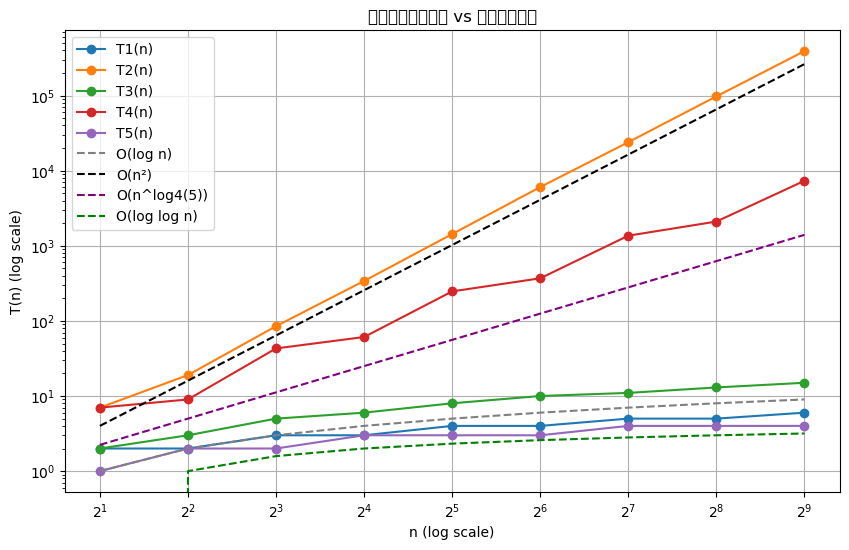

In [ ]:
# 借助AI

import math
import matplotlib.pyplot as plt
from functools import lru_cache

# 1. T(1)=1, T(n)=T(n/4)+1
@lru_cache(maxsize=None)
def T1(n):
    if n <= 1:  # 修复：<=1 就返回，避免 n=0
        return 1
    return T1(n // 4) + 1

# 2. T(1)=1, T(n)=3T(n/3)+n²
@lru_cache(maxsize=None)
def T2(n):
    if n <= 1:
        return 1
    return 3 * T2(n // 3) + n * n

# 3. T(1)=1, T(n)=T(2n/3)+1
@lru_cache(maxsize=None)
def T3(n):
    if n <= 1:
        return 1
    return T3((2 * n) // 3) + 1

# 4. T(1)=1, T(n)=5T(n/4)+n
@lru_cache(maxsize=None)
def T4(n):
    if n <= 1:
        return 1
    return 5 * T4(n // 4) + n

# 5. T(n)=1 (n≤2), T(n)=T(√n)+1
@lru_cache(maxsize=None)
def T5(n):
    if n <= 2:
        return 1
    return T5(int(math.isqrt(n))) + 1  # 使用整数平方根，更安全

# 生成数据点（小一点，避免递归过深）
n_values = [2**i for i in range(1, 10)]  # 2 ~ 512
labels = ["T1(n)", "T2(n)", "T3(n)", "T4(n)", "T5(n)"]
funcs = [T1, T2, T3, T4, T5]

# 绘图
plt.figure(figsize=(10, 6))
for func, label in zip(funcs, labels):
    y = [func(n) for n in n_values]
    plt.plot(n_values, y, label=label, marker='o')

# 理论对比曲线
plt.plot(n_values, [math.log2(n) for n in n_values], '--', label="O(log n)", color='gray')
plt.plot(n_values, [n**2 for n in n_values], '--', label="O(n²)", color='black')
plt.plot(n_values, [n**(math.log(5,4)) for n in n_values], '--', label="O(n^log4(5))", color='purple')
plt.plot(n_values, [math.log2(math.log2(n)) for n in n_values], '--', label="O(log log n)", color='green')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel("n (log scale)")
plt.ylabel("T(n) (log scale)")
plt.title("递归函数增长曲线 vs 理论渐近上界")
plt.legend()
plt.grid(True)
plt.show()


## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw1-2.jpg"> </div>

idea:

In [ ]:
# add your code here
# your algorithm time complexity is:

## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea:

In [8]:
# 思路分析
# 先把 profits 数组转换成价格数组 prices
# 双重循环枚举所有 i < j 的组合，计算 prices[j] - prices[i]，记录最大值和对应的日期

# 时间复杂度分析
# 转换价格数组：O(n)
# 双重循环枚举：O(n^2)
# 总时间复杂度：O(n^2)，空间复杂度 O(n)


def max_profit_bruteforce(profits):
    if len(profits) < 2:
        return 0, None, None  # 无法交易
    
    # 1. 转换为价格数组（假设初始价格为0）
    prices = []
    current_price = 0
    for p in profits:
        current_price += p
        prices.append(current_price)
    
    max_profit = 0
    buy_day = None
    sell_day = None
    n = len(prices)
    
    # 2. 双重循环枚举所有可能的买入和卖出
    for i in range(n):
        for j in range(i + 1, n):
            profit = prices[j] - prices[i]
            if profit > max_profit:
                max_profit = profit
                buy_day = i + 1  # 题目中的日期从1开始
                sell_day = j + 1
    
    return max_profit, buy_day, sell_day

# 测试例子
profits = [3, 2, 1, -7, 5, 2, -1, 3, -1]
profit, buy, sell = max_profit_bruteforce(profits)
print(f"最大利润: {profit}, 买入日期: {buy}, 卖出日期: {sell}")

最大利润: 9, 买入日期: 4, 卖出日期: 8


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea:

In [7]:
# 思路分析
# 题目给定边界条件：A[1] > A[2] 且 A[n-1] < A[n]，则数组开头是 “下降” 的，结尾是 “上升” 的，中间必然存在局部最小值。
# 取中间位置 mid，比较 A[mid] 与左右邻居：
# 如果 A[mid] 同时小于左右邻居，它本身就是局部最小值，直接返回。
# 如果 A[mid] > A[mid-1]，那么左半部分（[left, mid-1]）一定存在局部最小值（因为开头是下降的，而 mid 处比左边大，相当于左半部分的结尾是上升的，和题目原数组的边界条件一致），所以递归搜索左半部分。
# 否则（A[mid] > A[mid+1]），右半部分（[mid+1, right]）一定存在局部最小值，递归搜索右半部分。

# 时间复杂度分析
# 每次搜索范围减半，时间复杂度为 O(log n)。


def find_one_local_min(arr):
    left = 0
    right = len(arr) - 1
    # 边界条件保证了arr[0] > arr[1]，arr[-2] < arr[-1]
    while left < right:
        mid = (left + right) // 2
        # 检查是否是局部最小
        if arr[mid] < arr[mid-1] and arr[mid] < arr[mid+1]:
            return arr[mid]
        elif arr[mid] > arr[mid-1]:
            # 左边一定有局部最小
            right = mid - 1
        else:
            # 右边一定有局部最小
            left = mid + 1
    # 循环结束时left == right，且一定满足局部最小条件
    return arr[left]

# 测试
A = [9, 3, 7, 2, 1, 4, 5]
print(find_one_local_min(A))

1


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:

In [ ]:
# 思路分析
# 选择 Python 内置的 sorted() 函数（底层为Timsort，时间复杂度 O(n\logn)），先对整个数组排序，再取前 k 个元素，按升序输出。

# 时间复杂度分析
# 排序阶段：O(n\log n)
# 取前 k 个元素：O(k)
# 整体时间复杂度：O(n\log n)

def top_k_smallest_sort(arr, k):
    # 排序数组
    sorted_arr = sorted(arr)
    # 取前k个
    return sorted_arr[:k]

# 测试示例
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
print(top_k_smallest_sort(arr, k))

[1, 2, 3]


In [5]:
# 思路分析
# 建堆方式：往空堆中逐个插入元素，每插入一个元素都调整堆结构
# 建堆完成后，调用 heappop()k次，每次弹出堆顶的最小值，即可按顺序得到前k个最小数

# 时间复杂度分析
# 建堆阶段：每次插入操作时间复杂度为 O(\logi)（i 为当前堆大小），n 次插入总时间为 O(n\logn)
# 取 k 次最小值：每次 heappop() 为 O(\logn)，k次为 O(k\logn)
# 整体时间复杂度：O(n\logn)（当 k ≤ n 时）

import heapq

def top_k_smallest_heap_insert(arr, k):
    heap = []
    # 往空堆中逐个插入元素
    for num in arr:
        heapq.heappush(heap, num)
    
    # 调用k次Extract-min
    result = []
    for _ in range(k):
        result.append(heapq.heappop(heap))
    return result

# 测试示例
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
print(top_k_smallest_heap_insert(arr, k))

[1, 2, 3]


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

idea:

In [4]:
# 思路分析
# 初始化一个空栈stack，用于存放当前存活的星球（按从左到右的顺序）
# 遍历数组A中的每个星球 a：
# 如果 a > 0（向右运动），直接将其压入栈中。因为它不会与栈中任何星球相撞（栈中星球要么向右，要么向左但已位于其左侧，不会相向）
# 如果 a < 0（向左运动），则需要与栈顶的星球（如果存在且向右运动）进行碰撞比较：
# 当栈非空且栈顶元素 top > 0 时，计算两者的质量（top_mass = top，cur_mass = -a）：
# 若 top_mass > cur_mass：当前星球消失，退出碰撞循环
# 若 top_mass < cur_mass：栈顶星球消失（弹出），继续与新的栈顶比较
# 若 top_mass == cur_mass：根据规则，向左的星球消失，因此当前星球消失，栈顶星球保留，退出碰撞循环
# 如果栈为空或栈顶元素为负数（即同向左），则将当前星球直接压入栈中
# 遍历结束后，栈中元素即为最终存活的星球，且保持原始相对顺序

# 时间复杂度分析
# 每个星球最多入栈一次、出栈一次，整体操作次数为O(n)
# 因此时间复杂度为O(n)，空间复杂度为O(n)

def asteroid_collision(asteroids):
    """
    模拟星球碰撞，返回最终存活的星球列表。
    :param asteroids: List[int] 输入数组，正数向右，负数向左
    :return: List[int] 存活星球列表
    """
    stack = []
    for a in asteroids:
        if a > 0:
            stack.append(a)
        else:
            # a < 0，向左运动
            while stack and stack[-1] > 0:
                top = stack[-1]
                if top > -a:  # 栈顶质量更大，当前星球消失
                    break
                elif top < -a:  # 当前质量更大，栈顶消失
                    stack.pop()
                else:  # 质量相等，向左的消失，向右的保留
                    break
            else:
                # 如果循环正常结束（栈空或栈顶为负），则当前星球入栈
                stack.append(a)
    return stack

# 测试示例
if __name__ == "__main__":
    # 示例1
    A1 = [-3, -6, 2, 8, 5, -8, 9, -2, 1]
    print(asteroid_collision(A1))  # 输出: [-3, -6, 2, 8, 9, 1]

    # 示例2
    A2 = [23, -8, 9, -3, -7, 9, -23, 22]
    print(asteroid_collision(A2))  # 输出: [23, 22]


[-3, -6, 2, 8, 9, 1]
[23, 22]


## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
# 借助AI

# 思路分析
# 采用动态规划（DP） 解决 0-1 背包问题，通过子问题的最优解推导全局最优解
# 定义 dp[i][j] 表示：前i个物品中，在背包容量为j时能获得的最大价值。
# 对于第i个物品（重量w_i，价值v_i）：
# 若不选该物品：dp[i][j] = dp[i-1][j]（继承前i-1个物品的最优解）
# 若选该物品（需满足j ≥ w_i）：dp[i][j] = max(dp[i-1][j], dp[i-1][j - w_i] + v_i)
# dp[0][j] = 0（0 个物品时，价值为 0）
# dp[i][0] = 0（容量为 0 时，价值为 0）

# 时间复杂度分析
# 时间复杂度：O(n * C)，其中n为物品数量（4），C为背包容量（9）
# 空间复杂度：O(n * C)


def knapsack_01(items, capacity):
    n = len(items)
    # 初始化DP表：(n+1)行, (capacity+1)列
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]
    
    for i in range(1, n + 1):
        w, v = items[i-1]  # 当前物品的重量和价值
        for j in range(1, capacity + 1):
            if j < w:
                # 容量不足，无法选当前物品
                dp[i][j] = dp[i-1][j]
            else:
                # 容量足够，取选/不选的最大值
                dp[i][j] = max(dp[i-1][j], dp[i-1][j - w] + v)
    return dp[n][capacity]

# 问题数据
items = [(5,10), (4,40), (6,30), (3,50)]
capacity = 9

max_value = knapsack_01(items, capacity)
print(f"小推车能装的最大价值为: {max_value}")

小推车能装的最大价值为: 90


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:

In [ ]:
# 借助AI

# 思路分析
# 二叉搜索树（BST）的核心性质是：中序遍历序列是严格递增的有序序列。
# 题目中恰好两个节点的值被交换，会导致中序遍历序列出现1个或2个逆序对：

# 情况 1：两个交换节点不相邻 → 序列中出现2个逆序对
# 情况 2：两个交换节点相邻 → 序列中出现1个逆序对

# 中序遍历：在遍历过程中，记录当前节点与前一个节点，找出所有逆序对。
# 定位错误节点：
# 若存在2个逆序对：第一个逆序对的较大节点、第二个逆序对的较小节点，就是被交换的两个节点。
# 若存在1个逆序对：逆序对的两个节点就是被交换的两个节点。

# 时间复杂度分析
# 中序遍历整棵树仅需访问每个节点一次，时间复杂度为O(n)，n为节点总数。
# 空间复杂度：若使用递归实现，递归栈深度为树的高度，最坏情况（链状树）为O(n)

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def recoverTree(self, root: TreeNode) -> None:
        """
        Do not return anything, modify root in-place instead.
        """
        # 记录错误节点
        self.first = None
        self.second = None
        # 记录前一个节点，初始化为负无穷大
        self.prev = TreeNode(float('-inf'))
        
        def inorder(node: TreeNode):
            if not node:
                return
            # 左子树
            inorder(node.left)
            
            # 检查逆序对
            if self.first is None and self.prev.val > node.val:
                self.first = self.prev
            if self.first is not None and self.prev.val > node.val:
                self.second = node
            
            self.prev = node
            
            # 右子树
            inorder(node.right)
        
        inorder(root)
        # 交换两个错误节点的值
        self.first.val, self.second.val = self.second.val, self.first.val


# 辅助函数：根据列表构建二叉树（用于测试）
def build_tree(nodes, index=0):
    if index >= len(nodes) or nodes[index] is None:
        return None
    root = TreeNode(nodes[index])
    root.left = build_tree(nodes, 2*index + 1)
    root.right = build_tree(nodes, 2*index + 2)
    return root

# 辅助函数：将二叉树转为列表（层序遍历，便于输出）
def tree_to_list(root):
    if not root:
        return []
    res = []
    queue = [root]
    while queue:
        node = queue.pop(0)
        if node:
            res.append(node.val)
            queue.append(node.left)
            queue.append(node.right)
        else:
            res.append(None)
    # 去除末尾多余的None
    while res and res[-1] is None:
        res.pop()
    return res

# 测试用例1
print("=== 测试用例1 ===")
root1 = build_tree([1,3,None,None,2])
print("原树层序遍历：", tree_to_list(root1))
Solution().recoverTree(root1)
print("恢复后层序遍历：", tree_to_list(root1))

# 测试用例2
print("\n=== 测试用例2 ===")
root2 = build_tree([3,1,4,None,None,2])
print("原树层序遍历：", tree_to_list(root2))
Solution().recoverTree(root2)
print("恢复后层序遍历：", tree_to_list(root2))

=== 测试用例1 ===
原树层序遍历： [1, 3, None, None, 2]
恢复后层序遍历： [3, 1, None, None, 2]

=== 测试用例2 ===
原树层序遍历： [3, 1, 4, None, None, 2]
恢复后层序遍历： [2, 1, 4, None, None, 3]


## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
# add your code here
# your algorithm time complexity is:

## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea:

In [ ]:
# 借助AI

# 思路分析
# 这道题是遍历二叉树的所有从根到叶子的路径，将路径上的数字拼接成整数并求和
# 核心思想：深度优先搜索（DFS）
# 我们可以在遍历过程中维护一个变量current_sum，表示当前路径已形成的数字
# 每访问一个节点，就更新current_sum = current_sum * 10 + node.val
# 当访问到叶子节点（左右子节点都为空）时，将current_sum 累加到最终结果中
# 递归遍历左子树和右子树，完成所有路径的计算

# 二、时间复杂度分析
# 时间复杂度：O(n)，其中 n 是二叉树的节点数。每个节点仅被访问一次。
# 空间复杂度：O(h)，其中 h 是二叉树的高度。递归调用栈的深度等于树的高度，最坏情况下（树退化为链表）为 O(n)。

# 二叉树节点定义
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def sumNumbers(self, root: TreeNode) -> int:
        self.total = 0
        
        def dfs(node, current_sum):
            if not node:
                return
            # 更新当前路径的数字
            current_sum = current_sum * 10 + node.val
            # 到达叶子节点，累加到总和
            if not node.left and not node.right:
                self.total += current_sum
                return
            # 递归遍历左右子树
            dfs(node.left, current_sum)
            dfs(node.right, current_sum)
        
        dfs(root, 0)
        return self.total

# 辅助函数：根据列表构建二叉树（方便测试）
def build_tree(nums, index=0):
    if index >= len(nums) or nums[index] is None:
        return None
    root = TreeNode(nums[index])
    root.left = build_tree(nums, 2 * index + 1)
    root.right = build_tree(nums, 2 * index + 2)
    return root

# 测试示例
if __name__ == "__main__":
    sol = Solution()
    # 示例1
    root1 = build_tree([1, 2, 3])
    print(sol.sumNumbers(root1))  # 输出 25
    
    # 示例2
    root2 = build_tree([4, 9, 0, 5, 1])
    print(sol.sumNumbers(root2))  # 输出 1026

25
1026
